In [ ]:
!git clone https://github.com/emcr30/sdm-andes-tropicales.git
%cd sdm-andes-tropicales

Cloning into 'sdm-andes-tropicales'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 20 (delta 4), reused 19 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 15.73 KiB | 7.87 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/sdm-andes-tropicales/sdm-andes-tropicales


In [ ]:
!pip install pygbif pyinaturalist rasterio geopandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import os

REPO = "/content/sdm-andes-tropicales"
os.chdir(REPO)

for carpeta in ["data/raw", "data/processed", "notebooks", "src", "outputs/figures", "outputs/models"]:
    os.makedirs(carpeta, exist_ok=True)

print(os.listdir("."))

['data', '.git', 'notebooks', 'outputs', '.gitignore', 'src']


# **GBIF**


In [ ]:
from pygbif import occurrences as occ
from pygbif import species as sp
import pandas as pd

especies = {
    "Xenoglaux_loweryi": "Xenoglaux loweryi",
    "Cinclodes_palliatus": "Cinclodes palliatus",
    "Telmatobius_macrostomus": "Telmatobius macrostomus",
}

resultados_gbif = {}

def descargar_todos(taxon_key, year_range, page_size):
    all_records = []
    offset = 0
    while True:
        # Ensure the 'occurrenceStatus' parameter is set to 'present' to filter valid occurrences
        response = occ.search(taxonKey=taxon_key, year=year_range, limit=page_size, offset=offset, occurrenceStatus="present")
        records = response.get("results", [])

        if not records:
            break
        all_records.extend(records)
        offset += page_size
    return all_records


for nombre_archivo, nombre_cientifico in especies.items():
    match = sp.name_backbone(scientificName=nombre_cientifico)
    taxon_key = match["usage"]["key"]
    print(f"{nombre_cientifico} -> taxonKey {taxon_key}")

    registros_completos = descargar_todos(taxon_key, year_range="1980,2024", page_size=300)
    df = pd.DataFrame(registros_completos)

    if not df.empty:
        cols = ["species", "decimalLatitude", "decimalLongitude", "eventDate", "year", "basisOfRecord", "coordinateUncertaintyInMeters"]
        cols = [c for c in cols if c in df.columns]
        df = df[cols]
    resultados_gbif[nombre_archivo] = df
    df.to_csv(f"data/raw/{nombre_archivo}_gbif.csv", index=False)
    print(f"  {len(df)} registros guardados\n")

Xenoglaux loweryi -> taxonKey 2497649
  919 registros guardados

Cinclodes palliatus -> taxonKey 2485082
  1036 registros guardados

Telmatobius macrostomus -> taxonKey 10886038
  16 registros guardados



# **iNaturalist**

In [ ]:
from pyinaturalist import get_observations
import pandas as pd

especies = {
    "Xenoglaux_loweryi": {"nombre": "Xenoglaux loweryi", "taxon_id": 20377},
    "Cinclodes_palliatus": {"nombre": "Cinclodes palliatus", "taxon_id": 11382},
    "Telmatobius_macrostomus": {"nombre": "Telmatobius macrostomus", "taxon_id": 135145},
}

def descargar_inat_todos(taxon_id, place_id=7513, per_page=200, d1=None, d2=None, quality_grade=None):
    todos = []
    page = 1
    while True:
        params = dict(taxon_id=taxon_id, place_id=place_id, per_page=per_page, page=page)
        if d1: params["d1"] = d1
        if d2: params["d2"] = d2
        if quality_grade: params["quality_grade"] = quality_grade

        obs = get_observations(**params)
        results = obs.get("results", [])
        todos.extend(results)

        if len(results) < per_page:
            break
        page += 1
    return todos

for nombre_archivo, info in especies.items():
    resultados = descargar_inat_todos(
        info["taxon_id"],
        d1="1980-01-01",
        d2="2024-12-31",
        quality_grade="research"
    )

    registros = []
    for o in resultados:
        if o.get("geojson"):
            lon, lat = o["geojson"]["coordinates"]
            registros.append({
                "species": info["nombre"],
                "decimalLatitude": lat,
                "decimalLongitude": lon,
                "observed_on": o.get("observed_on"),
            })

    df = pd.DataFrame(registros)
    df.to_csv(f"data/raw/{nombre_archivo}_inat.csv", index=False)
    print(f"{info['nombre']}: {len(df)} registros de iNaturalist guardados")

Xenoglaux loweryi: 20 registros de iNaturalist guardados
Cinclodes palliatus: 26 registros de iNaturalist guardados
Telmatobius macrostomus: 39 registros de iNaturalist guardados


# **WorldClim**

In [ ]:
import requests, zipfile, os

url = "https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_5m_bio.zip"
zip_path = "/content/wc2.1_5m_bio.zip"

r = requests.get(url, stream=True)
total = int(r.headers.get("content-length", 0))
descargado = 0

with open(zip_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=1024*1024):
        f.write(chunk)
        descargado += len(chunk)
        if total:
            print(f"\r{descargado/1e6:.1f} MB / {total/1e6:.1f} MB", end="")

print()

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/worldclim_raw")

print(os.listdir("/content/worldclim_raw")[:5])

179.6 MB / 179.6 MB
['wc2.1_5m_bio_15.tif', 'wc2.1_5m_bio_9.tif', 'wc2.1_5m_bio_19.tif', 'wc2.1_5m_bio_2.tif', 'wc2.1_5m_bio_18.tif']


In [ ]:
import rasterio
from rasterio.windows import from_bounds
import os

bbox = {"west": -81, "south": -18, "east": -68, "north": 0}

os.makedirs("/content/drive/MyDrive/tesis_sdm/worldclim_clip", exist_ok=True)

for i in range(1, 20):
    src_path = f"/content/worldclim_raw/wc2.1_5m_bio_{i}.tif"
    if not os.path.exists(src_path):
        continue
    with rasterio.open(src_path) as src:
        window = from_bounds(bbox["west"], bbox["south"], bbox["east"], bbox["north"], src.transform)
        data = src.read(1, window=window)
        transform = src.window_transform(window)

        out_path = f"/content/drive/MyDrive/tesis_sdm/worldclim_clip/bio_{i}.tif"
        with rasterio.open(
            out_path, "w", driver="GTiff",
            height=data.shape[0], width=data.shape[1],
            count=1, dtype=data.dtype,
            crs=src.crs, transform=transform,
            nodata=src.nodata   # <-- esto es lo que faltaba
        ) as dst:
            dst.write(data, 1)
    print(f"bio_{i} recortado y guardado en Drive")

bio_1 recortado y guardado en Drive
bio_2 recortado y guardado en Drive
bio_3 recortado y guardado en Drive
bio_4 recortado y guardado en Drive
bio_5 recortado y guardado en Drive
bio_6 recortado y guardado en Drive
bio_7 recortado y guardado en Drive
bio_8 recortado y guardado en Drive
bio_9 recortado y guardado en Drive
bio_10 recortado y guardado en Drive
bio_11 recortado y guardado en Drive
bio_12 recortado y guardado en Drive
bio_13 recortado y guardado en Drive
bio_14 recortado y guardado en Drive
bio_15 recortado y guardado en Drive
bio_16 recortado y guardado en Drive
bio_17 recortado y guardado en Drive
bio_18 recortado y guardado en Drive
bio_19 recortado y guardado en Drive


NoData ahora declarado: -3.3999999521443642e+38
Min real: -3.2895 Max real: 27.184458


/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


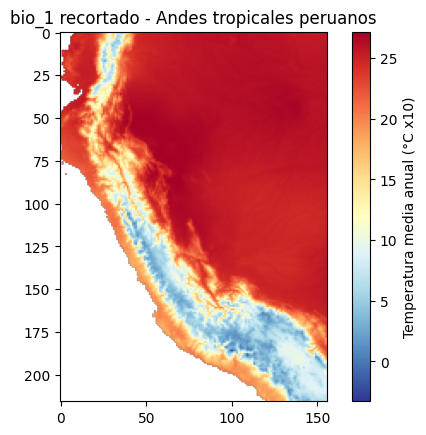

In [ ]:
import matplotlib.pyplot as plt
import rasterio

with rasterio.open("/content/drive/MyDrive/tesis_sdm/worldclim_clip/bio_1.tif") as src:
    print("NoData ahora declarado:", src.nodata)
    data = src.read(1, masked=True)
    print("Min real:", data.min(), "Max real:", data.max())

    plt.imshow(data, cmap="RdYlBu_r")
    plt.colorbar(label="Temperatura media anual (°C x10)")
    plt.title("bio_1 recortado - Andes tropicales peruanos")
    plt.show()

In [ ]:
import rasterio
from rasterio.windows import from_bounds
import os

bbox = {"west": -81, "south": -18, "east": -68, "north": 0}
os.makedirs("/content/drive/MyDrive/tesis_sdm/worldclim_clip", exist_ok=True)

for i in range(1, 20):
    src_path = f"/content/worldclim_raw/wc2.1_5m_bio_{i}.tif"
    if not os.path.exists(src_path):
        print(f"Falta bio_{i}, revisar")
        continue
    with rasterio.open(src_path) as src:
        window = from_bounds(bbox["west"], bbox["south"], bbox["east"], bbox["north"], src.transform)
        data = src.read(1, window=window)
        transform = src.window_transform(window)

        out_path = f"/content/drive/MyDrive/tesis_sdm/worldclim_clip/bio_{i}.tif"
        with rasterio.open(
            out_path, "w", driver="GTiff",
            height=data.shape[0], width=data.shape[1],
            count=1, dtype=data.dtype,
            crs=src.crs, transform=transform,
            nodata=src.nodata
        ) as dst:
            dst.write(data, 1)
    print(f"bio_{i} recortado ✓")

bio_1 recortado ✓
bio_2 recortado ✓
bio_3 recortado ✓
bio_4 recortado ✓
bio_5 recortado ✓
bio_6 recortado ✓
bio_7 recortado ✓
bio_8 recortado ✓
bio_9 recortado ✓
bio_10 recortado ✓
bio_11 recortado ✓
bio_12 recortado ✓
bio_13 recortado ✓
bio_14 recortado ✓
bio_15 recortado ✓
bio_16 recortado ✓
bio_17 recortado ✓
bio_18 recortado ✓
bio_19 recortado ✓


In [ ]:
import os
archivos = sorted(os.listdir("/content/drive/MyDrive/tesis_sdm/worldclim_clip"))
print(f"{len(archivos)} archivos:", archivos)

19 archivos: ['bio_1.tif', 'bio_10.tif', 'bio_11.tif', 'bio_12.tif', 'bio_13.tif', 'bio_14.tif', 'bio_15.tif', 'bio_16.tif', 'bio_17.tif', 'bio_18.tif', 'bio_19.tif', 'bio_2.tif', 'bio_3.tif', 'bio_4.tif', 'bio_5.tif', 'bio_6.tif', 'bio_7.tif', 'bio_8.tif', 'bio_9.tif']


# **Mapa de puntos presencia**

**Solo GBIF**

/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


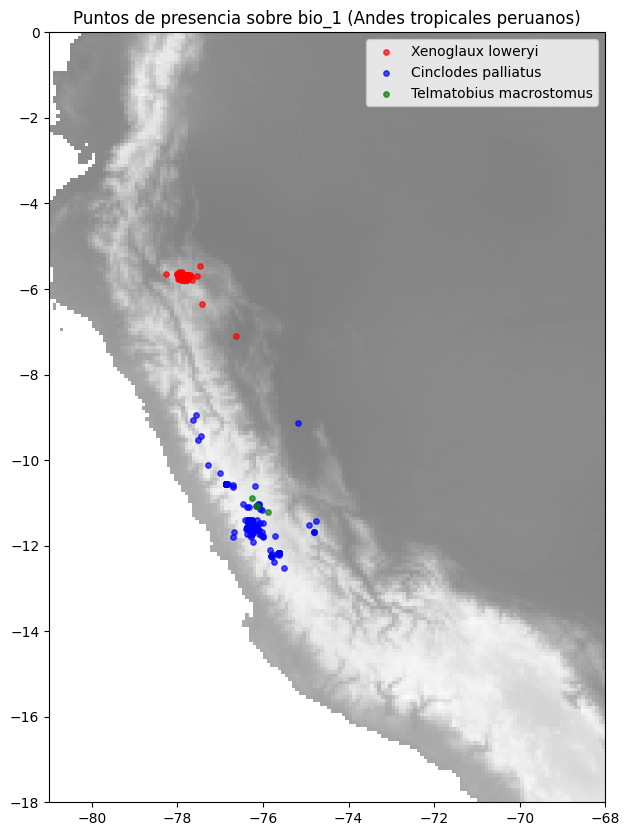

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd

# cargar los 3 CSVs de GBIF (ajusta si también quieres combinar con iNaturalist ya)
especies_archivos = {
    "Xenoglaux loweryi": "data/raw/Xenoglaux_loweryi_gbif.csv",
    "Cinclodes palliatus": "data/raw/Cinclodes_palliatus_gbif.csv",
    "Telmatobius macrostomus": "data/raw/Telmatobius_macrostomus_gbif.csv",
}

with rasterio.open("/content/drive/MyDrive/tesis_sdm/worldclim_clip/bio_1.tif") as src:
    fondo = src.read(1, masked=True)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(fondo, cmap="Greys", extent=extent, alpha=0.5)

colores = ["red", "blue", "green"]
for (especie, archivo), color in zip(especies_archivos.items(), colores):
    df = pd.read_csv(archivo)
    df = df.dropna(subset=["decimalLatitude", "decimalLongitude"])
    ax.scatter(df["decimalLongitude"], df["decimalLatitude"], s=15, label=especie, color=color, alpha=0.7)

ax.legend()
ax.set_title("Puntos de presencia sobre bio_1 (Andes tropicales peruanos)")
plt.show()

**Ambas fuentes**

In [ ]:
import pandas as pd
import os

especies = ["Xenoglaux_loweryi", "Cinclodes_palliatus", "Telmatobius_macrostomus"]

for especie in especies:
    gbif_path = f"data/raw/{especie}_gbif.csv"
    inat_path = f"data/raw/{especie}_inat.csv"

    n_gbif = len(pd.read_csv(gbif_path)) if os.path.exists(gbif_path) else 0
    n_inat = len(pd.read_csv(inat_path)) if os.path.exists(inat_path) else 0

    print(f"{especie}: GBIF={n_gbif}, iNaturalist={n_inat}, TOTAL(antes de deduplicar)={n_gbif + n_inat}")

Xenoglaux_loweryi: GBIF=919, iNaturalist=20, TOTAL(antes de deduplicar)=939
Cinclodes_palliatus: GBIF=1036, iNaturalist=26, TOTAL(antes de deduplicar)=1062
Telmatobius_macrostomus: GBIF=16, iNaturalist=39, TOTAL(antes de deduplicar)=55


/usr/local/lib/python3.12/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


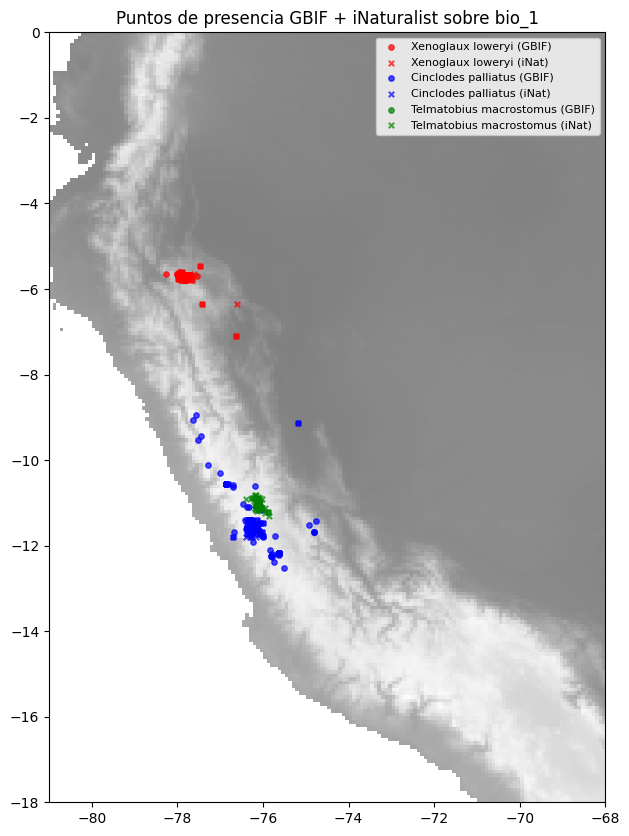

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd

especies_gbif = {
    "Xenoglaux loweryi": "data/raw/Xenoglaux_loweryi_gbif.csv",
    "Cinclodes palliatus": "data/raw/Cinclodes_palliatus_gbif.csv",
    "Telmatobius macrostomus": "data/raw/Telmatobius_macrostomus_gbif.csv",
}
especies_inat = {
    "Xenoglaux loweryi": "data/raw/Xenoglaux_loweryi_inat.csv",
    "Cinclodes palliatus": "data/raw/Cinclodes_palliatus_inat.csv",
    "Telmatobius macrostomus": "data/raw/Telmatobius_macrostomus_inat.csv",
}

with rasterio.open("/content/drive/MyDrive/tesis_sdm/worldclim_clip/bio_1.tif") as src:
    fondo = src.read(1, masked=True)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(fondo, cmap="Greys", extent=extent, alpha=0.5)

colores = ["red", "blue", "green"]
for (especie, color) in zip(especies_gbif.keys(), colores):
    df_gbif = pd.read_csv(especies_gbif[especie])
    df_gbif = df_gbif.dropna(subset=["decimalLatitude", "decimalLongitude"])

    df_inat = pd.read_csv(especies_inat[especie])
    df_inat = df_inat.dropna(subset=["decimalLatitude", "decimalLongitude"])

    ax.scatter(df_gbif["decimalLongitude"], df_gbif["decimalLatitude"], s=15, label=f"{especie} (GBIF)", color=color, alpha=0.7, marker="o")
    ax.scatter(df_inat["decimalLongitude"], df_inat["decimalLatitude"], s=15, label=f"{especie} (iNat)", color=color, alpha=0.7, marker="x")

ax.legend(fontsize=8)
ax.set_title("Puntos de presencia GBIF + iNaturalist sobre bio_1")
plt.show()

In [ ]:
import pandas as pd

df_gbif = pd.read_csv("data/raw/Telmatobius_macrostomus_gbif.csv")
df_inat = pd.read_csv("data/raw/Telmatobius_macrostomus_inat.csv")

df_gbif["fuente"] = "gbif"
df_inat["fuente"] = "inat"

combinado = pd.concat([
    df_gbif[["decimalLatitude", "decimalLongitude", "fuente"]],
    df_inat[["decimalLatitude", "decimalLongitude", "fuente"]]
], ignore_index=True).dropna()

# redondeamos a 4 decimales (~11m de precisión) para detectar duplicados casi exactos
combinado["lat_r"] = combinado["decimalLatitude"].round(4)
combinado["lon_r"] = combinado["decimalLongitude"].round(4)

antes = len(combinado)
combinado_dedup = combinado.drop_duplicates(subset=["lat_r", "lon_r"])
despues = len(combinado_dedup)

print(f"Antes de deduplicar: {antes}")
print(f"Después de deduplicar coordenadas casi-exactas: {despues}")
print(f"Duplicados eliminados: {antes - despues}")

Antes de deduplicar: 43
Después de deduplicar coordenadas casi-exactas: 40
Duplicados eliminados: 3


In [ ]:
import pandas as pd
from sklearn.neighbors import BallTree
import numpy as np

def combinar_fuentes(gbif_path, inat_path):
    """Combina GBIF + iNaturalist y elimina duplicados por coordenadas casi-exactas."""
    df_gbif = pd.read_csv(gbif_path)
    df_inat = pd.read_csv(inat_path)

    df_gbif["fuente"] = "gbif"
    df_inat["fuente"] = "inat"

    combinado = pd.concat([
        df_gbif[["decimalLatitude", "decimalLongitude", "fuente"]],
        df_inat[["decimalLatitude", "decimalLongitude", "fuente"]]
    ], ignore_index=True).dropna()

    combinado["lat_r"] = combinado["decimalLatitude"].round(4)
    combinado["lon_r"] = combinado["decimalLongitude"].round(4)
    combinado = combinado.drop_duplicates(subset=["lat_r", "lon_r"]).drop(columns=["lat_r", "lon_r"])

    return combinado.reset_index(drop=True)


def rarefaccion_espacial(df, umbral_km, lat_col="decimalLatitude", lon_col="decimalLongitude"):
    """
    Aplica rarefacción espacial: conserva un solo punto por vecindad definida por umbral_km.
    Método: recorre los puntos y descarta cualquiera que esté a menos de umbral_km
    de un punto ya conservado.
    """
    coords_rad = np.radians(df[[lat_col, lon_col]].values)
    tree = BallTree(coords_rad, metric="haversine")

    radio_tierra_km = 6371.0
    umbral_rad = umbral_km / radio_tierra_km

    conservados = []
    descartados = set()

    for i in range(len(df)):
        if i in descartados:
            continue
        conservados.append(i)
        vecinos = tree.query_radius([coords_rad[i]], r=umbral_rad)[0]
        for v in vecinos:
            if v != i:
                descartados.add(v)

    return df.iloc[conservados].reset_index(drop=True)

# **Umbrales**

In [ ]:
import pandas as pd
from sklearn.neighbors import BallTree
import numpy as np

def combinar_fuentes(gbif_path, inat_path):
    """Combina GBIF + iNaturalist y elimina duplicados por coordenadas casi-exactas."""
    df_gbif = pd.read_csv(gbif_path)
    df_inat = pd.read_csv(inat_path)

    df_gbif["fuente"] = "gbif"
    df_inat["fuente"] = "inat"

    combinado = pd.concat([
        df_gbif[["decimalLatitude", "decimalLongitude", "fuente"]],
        df_inat[["decimalLatitude", "decimalLongitude", "fuente"]]
    ], ignore_index=True).dropna()

    combinado["lat_r"] = combinado["decimalLatitude"].round(4)
    combinado["lon_r"] = combinado["decimalLongitude"].round(4)
    combinado = combinado.drop_duplicates(subset=["lat_r", "lon_r"]).drop(columns=["lat_r", "lon_r"])

    return combinado.reset_index(drop=True)


def rarefaccion_espacial(df, umbral_km, lat_col="decimalLatitude", lon_col="decimalLongitude"):
    """
    Aplica rarefacción espacial: conserva un solo punto por vecindad definida por umbral_km.
    Método: recorre los puntos y descarta cualquiera que esté a menos de umbral_km
    de un punto ya conservado.
    """
    coords_rad = np.radians(df[[lat_col, lon_col]].values)
    tree = BallTree(coords_rad, metric="haversine")

    radio_tierra_km = 6371.0
    umbral_rad = umbral_km / radio_tierra_km

    conservados = []
    descartados = set()

    for i in range(len(df)):
        if i in descartados:
            continue
        conservados.append(i)
        vecinos = tree.query_radius([coords_rad[i]], r=umbral_rad)[0]
        for v in vecinos:
            if v != i:
                descartados.add(v)

    return df.iloc[conservados].reset_index(drop=True)

especie = "Telmatobius_macrostomus"
combinado = combinar_fuentes(
    f"data/raw/{especie}_gbif.csv",
    f"data/raw/{especie}_inat.csv"
)
print(f"Total combinado sin duplicados: {len(combinado)}")

for umbral in [0.5, 1, 2, 5]:
    resultado = rarefaccion_espacial(combinado, umbral_km=umbral)
    print(f"Umbral {umbral} km -> quedan {len(resultado)} registros")

Total combinado sin duplicados: 40
Umbral 0.5 km -> quedan 40 registros
Umbral 1 km -> quedan 40 registros
Umbral 2 km -> quedan 35 registros
Umbral 5 km -> quedan 21 registros


In [ ]:
umbral_elegido = 1  # ajusta según lo que veas arriba
final = rarefaccion_espacial(combinado, umbral_km=umbral_elegido)
final.to_csv(f"data/processed/{especie}_rarefied.csv", index=False)
print(f"Guardado: {len(final)} registros finales para {especie}")

Guardado: 40 registros finales para Telmatobius_macrostomus


#Solo *Telmatobius*

In [ ]:
import folium
import pandas as pd

df_gbif = pd.read_csv("data/raw/Telmatobius_macrostomus_gbif.csv").dropna(subset=["decimalLatitude","decimalLongitude"])
df_inat = pd.read_csv("data/raw/Telmatobius_macrostomus_inat.csv").dropna(subset=["decimalLatitude","decimalLongitude"])

# centro aproximado en Junín
m = folium.Map(location=[-11.0, -76.0], zoom_start=9)

for _, row in df_gbif.iterrows():
    folium.CircleMarker([row["decimalLatitude"], row["decimalLongitude"]], radius=4, color="red", fill=True, popup="GBIF").add_to(m)

for _, row in df_inat.iterrows():
    folium.CircleMarker([row["decimalLatitude"], row["decimalLongitude"]], radius=4, color="blue", fill=True, popup="iNat").add_to(m)

m

<folium.folium.Map object at 0x78976f3a56a0>

# **ReadMe**

In [ ]:
import os

readme_sprint1 = """
## Sprint 1 - Comprensión del dominio y datos

### Fuentes usadas
- GBIF: ocurrencias con coordenadas, país=PE, año 1980-2024
- iNaturalist: taxon_id confirmado por especie (place_id correcto = 7513, Perú)
- WorldClim v2.1, resolución 5 arc-min (bio1-bio19), recortado a bbox Andes tropicales peruanos

### Decisiones y hallazgos importantes
- Telmatobius macrostomus: el filtro 1980-2024 deja solo 4 registros GBIF (mayoría de la
  colección es histórica, 1916-1950).
- Recorte de WorldClim para preservar el valor NoData (se perdía al escribir
  el raster recortado con rasterio, causando errores de visualización).
"""

os.makedirs("docs", exist_ok=True)
with open("docs/notas_sprint1.md", "w") as f:
    f.write(readme_sprint1)

# **GitHub**

In [ ]:
gitignore_content = """
# datos pesados que NO deben ir a GitHub
data/raw/*.tif
data/raw/*.zip
worldclim_raw/
*.tif

# archivos temporales de Colab
.ipynb_checkpoints/
__pycache__/
"""

with open("/content/sdm-andes-tropicales/.gitignore", "w") as f:
    f.write(gitignore_content)

In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   data/raw/Cinclodes_palliatus_gbif.csv
	modified:   data/raw/Telmatobius_macrostomus_gbif.csv
	modified:   data/raw/Xenoglaux_loweryi_gbif.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	docs/

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add data/raw/*.csv .gitignore
!git commit -m "Sprint 1: descargas GBIF e iNaturalist"
!git push

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@faa7309260da.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git add data/raw/*.csv docs/notas_sprint1.md .gitignore
!git commit -m "Cierre Sprint 1: datos GBIF/iNat/WorldClim, correcciones documentadas"
!git push

[main 0088927] Cierre Sprint 1: datos GBIF/iNat/WorldClim, correcciones documentadas
 4 files changed, 59 insertions(+)
 create mode 100644 docs/notas_sprint1.md
fatal: could not read Username for 'https://github.com': No such device or address
